# Project Two: Predicting Future NBA All-Stars

## Research Question

**Can an NBA player's rookie-season statistics, and draft position predict whether they will become an NBA All-Star within their first seven seasons?**

### Prediction task
This is a **binary classification** problem.

### Target variable
`future_all_star`

- `1` = the player became an NBA All-Star within the first seven seasons of their career
- `0` = the player did not

### Planned models
1. Logistic Regression
2. Random Forest Classifier

The goal of this notebook is to build a player-level dataset, explore the data, prepare features, train and compare models, and interpret which rookie-season factors are most useful for predicting future All-Star status.


## Planned Data Source

## Data Source

This project uses NBA player data collected with the `nba_api` Python package. The analysis focuses on rookie seasons from 2003-04 through 2018-19.


In [15]:
import sys
!{sys.executable} -m pip install nba_api

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nba_api.stats.static import players
from nba_api.stats.endpoints import playercareerstats, commonplayerinfo

pd.set_option("display.max_columns", None)

print("Setup complete.")


Setup complete.


## Planned Features

### Direct rookie-season features
- Points per game
- Rebounds per game
- Assists per game
- Steals per game
- Blocks per game
- Turnovers per game
- Minutes per game
- Games played
- Field-goal percentage
- Three-point percentage
- Free-throw percentage
- Rookie age
- Draft position
- College attended

### Engineered features
- Points per 36 minutes
- Rebounds per 36 minutes
- Assists per 36 minutes
- True shooting percentage
- Power 4 college status
- Usage rate, if it is available consistently for the seasons included

### Target
- Future All-Star status within the player's first seven NBA seasons


In [17]:
# starting settings

START_DRAFT_YEAR = 2003
END_DRAFT_YEAR = 2018
ALL_STAR_WINDOW = 7

print("Planned draft-year range:", START_DRAFT_YEAR, "to", END_DRAFT_YEAR)
print("All-Star prediction window:", ALL_STAR_WINDOW, "seasons")


Planned draft-year range: 2003 to 2018
All-Star prediction window: 7 seasons


## Data-Quality Questions to Investigate

Before modeling, I will check:

- Missing values
- Duplicate players or seasons
- Players with very few rookie minutes or games
- Shooting percentages based on very small attempt totals
- Class imbalance in the All-Star target
- Whether per-game and per-36 statistics are too redundant
- Whether usage rate is available consistently
- How to represent undrafted players
- How to classify international, G League, and non-college players for the Power 4 feature
- Potential data leakage


## Next Steps

1. Identify the draft classes and players included in the project.
2. Pull each player's rookie-season statistics.
3. Pull player information such as draft pick, age, and college.
4. Engineer per-36 statistics, true shooting percentage, and Power 4 status.
5. Create the `future_all_star` target.
6. Explore class balance and feature distributions.
7. Select final features.
8. Split into training and testing data.
9. Establish a baseline.
10. Train Logistic Regression and Random Forest models.
11. Evaluate and interpret both models.


## Building the Player Dataset

The next step is to create one row per NBA player. Each row will contain rookie-season statistics, draft information, and a target showing whether the player became an All-Star within their first seven seasons.

In [18]:
from nba_api.stats.endpoints import leaguedashplayerstats
import time

In [19]:
seasons = [
    "2003-04", "2004-05", "2005-06", "2006-07",
    "2007-08", "2008-09", "2009-10", "2010-11",
    "2011-12", "2012-13", "2013-14", "2014-15",
    "2015-16", "2016-17", "2017-18", "2018-19"
]

len(seasons)

16

## Collect Rookie-Season Player Statistics

For each season, I will collect player statistics and keep players whose NBA experience is listed as zero years. This should identify players in their rookie season. The season-level data will then be combined into one dataset.

In [20]:
rookie_frames = []

for season in seasons:
    print("Pulling", season)

    stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        season_type_all_star="Regular Season"
    )

    season_df = stats.get_data_frames()[0]

    print(season, season_df.shape)
    rookie_frames.append(season_df)

    time.sleep(0.6)

all_season_stats = pd.concat(rookie_frames, ignore_index=True)

print("Combined shape:", all_season_stats.shape)
all_season_stats.head()

Pulling 2003-04
2003-04 (442, 69)
Pulling 2004-05
2004-05 (464, 69)
Pulling 2005-06
2005-06 (458, 69)
Pulling 2006-07
2006-07 (458, 69)
Pulling 2007-08
2007-08 (451, 69)
Pulling 2008-09
2008-09 (445, 69)
Pulling 2009-10
2009-10 (442, 69)
Pulling 2010-11
2010-11 (452, 69)
Pulling 2011-12
2011-12 (478, 69)
Pulling 2012-13
2012-13 (469, 69)
Pulling 2013-14
2013-14 (482, 69)
Pulling 2014-15
2014-15 (492, 69)
Pulling 2015-16
2015-16 (476, 67)
Pulling 2016-17
2016-17 (486, 69)
Pulling 2017-18
2017-18 (540, 69)
Pulling 2018-19
2018-19 (530, 69)
Combined shape: (7565, 69)


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,FP_HIGH_SCORE,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,FP_HIGH_SCORE_RANK,TEAM_COUNT
0,243,Aaron McKie,Aaron,1610612755,PHI,31.0,75,30,45,0.400,2116.925000,265,577,0.459,75,172,0.436,84,111,0.757,45,208,253,195,103,85,23,52,142,0,689,-42,1506.1,0,0,1428.0,1656.0,120,191,388,310,110,125,133,138,66,86,24,178,186,194,221,138,168,91,131,65,137,375,266,79,127,269,124,235,19,124,123.0,1
1,1425,Aaron Williams,Aaron,1610612751,NJN,32.0,72,39,33,0.542,1335.846667,172,342,0.503,1,3,0.333,105,155,0.677,101,193,294,81,89,34,46,20,187,0,450,-50,1075.3,1,0,986.0,1146.0,147,105,273,151,202,190,216,37,258,286,138,148,138,302,97,153,131,200,158,216,76,219,352,79,192,287,189,178,19,194,197.0,1
2,1502,Adonal Foyle,Adonal,1610612744,GSW,29.0,44,21,23,0.477,574.568333,59,130,0.454,0,0,0.000,19,35,0.543,54,113,167,17,21,6,46,11,68,0,137,-83,497.9,2,0,425.0,494.0,298,276,157,228,310,319,325,149,289,361,289,333,312,388,190,243,231,338,337,362,76,142,146,79,325,337,287,146,19,297,295.0,1
3,1559,Adrian Griffin,Adrian,1610612745,HOU,29.0,19,13,6,0.684,122.095000,5,18,0.278,1,2,0.500,0,4,0.000,1,18,19,10,3,7,2,0,17,0,11,-47,72.8,0,0,59.0,77.0,373,337,49,53,386,405,400,421,258,305,5,425,400,425,413,375,380,368,405,355,356,1,63,79,410,281,386,235,19,388,387.0,1
4,1733,Al Harrington,Al,1610612754,IND,24.0,79,58,21,0.734,2440.863333,421,909,0.463,21,77,0.273,185,252,0.734,163,345,508,131,163,80,22,80,250,0,1048,71,1997.1,12,0,1912.0,2124.0,77,4,141,28,77,56,64,128,146,140,214,76,73,245,43,50,45,141,59,80,139,422,423,79,68,93,85,47,19,81,89.0,1


In [21]:
print(all_season_stats.columns.tolist())

['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'FP_HIGH_SCORE', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'FP_HIGH_SCORE_RANK', 'TEAM_COUNT']


In [22]:
rookie_frames = []

for season in seasons:
    print("Pulling rookies:", season)

    stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        season_type_all_star="Regular Season",
        player_experience_nullable="Rookie"
    )

    season_df = stats.get_data_frames()[0]
    season_df["ROOKIE_SEASON"] = season

    print(season, season_df.shape)
    rookie_frames.append(season_df)

    time.sleep(0.6)

rookie_stats = pd.concat(rookie_frames, ignore_index=True)

print("Combined rookie shape:", rookie_stats.shape)
rookie_stats.head()

Pulling rookies: 2003-04
2003-04 (67, 70)
Pulling rookies: 2004-05
2004-05 (70, 70)
Pulling rookies: 2005-06
2005-06 (85, 70)
Pulling rookies: 2006-07
2006-07 (80, 70)
Pulling rookies: 2007-08
2007-08 (64, 70)
Pulling rookies: 2008-09
2008-09 (62, 70)
Pulling rookies: 2009-10
2009-10 (57, 70)
Pulling rookies: 2010-11
2010-11 (67, 70)
Pulling rookies: 2011-12
2011-12 (81, 70)
Pulling rookies: 2012-13
2012-13 (78, 70)
Pulling rookies: 2013-14
2013-14 (76, 70)
Pulling rookies: 2014-15
2014-15 (81, 70)
Pulling rookies: 2015-16
2015-16 (73, 70)
Pulling rookies: 2016-17
2016-17 (88, 70)
Pulling rookies: 2017-18
2017-18 (116, 70)
Pulling rookies: 2018-19
2018-19 (105, 70)
Combined rookie shape: (1250, 70)


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,FP_HIGH_SCORE,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,FP_HIGH_SCORE_RANK,TEAM_COUNT,ROOKIE_SEASON
0,2682,Alex Garcia,Alex,1610612759,SAS,24.0,2,2,0,1.000,12.678333,1,7,0.143,0,0,0.000,1,2,0.500,0,0,0,0,1,2,0,1,0,0,3,3,8.0,0,0,7.0,9.0,64,58,1,1,65,64,61,66,41,55,41,59,59,54,62,65,66,62,61,51,55,8,1,5,64,19,64,24,2,65,63,1,2003-04
1,1052,Ben Handlogten,Ben,1610612762,UTA,30.0,17,9,8,0.529,171.478333,25,47,0.532,0,0,0.000,18,27,0.667,22,33,55,6,10,3,4,6,32,0,68,-13,154.0,0,0,143.0,156.0,47,47,22,19,46,42,47,3,41,55,41,41,37,40,35,42,38,50,48,49,36,27,25,5,43,33,45,24,2,44,45,1,2003-04
2,2564,Boris Diaw,Boris,1610612737,ATL,22.0,76,28,48,0.368,1915.235000,140,313,0.447,6,26,0.231,56,93,0.602,111,231,342,182,126,59,37,15,191,0,342,-243,1187.4,1,0,1064.0,1336.0,7,19,63,47,7,20,21,20,25,26,35,22,15,51,7,6,7,8,9,11,7,40,61,5,20,64,11,14,2,13,11,1,2003-04
3,2599,Brandon Hunter,Brandon,1610612738,BOS,23.0,36,14,22,0.389,404.801667,53,116,0.457,0,3,0.000,19,43,0.442,50,68,118,19,22,13,1,16,40,0,125,-4,315.1,1,0,290.0,323.0,39,36,30,44,39,36,39,17,41,42,41,39,33,59,20,33,28,38,36,36,50,42,28,5,38,26,37,14,2,37,37,1,2003-04
4,2567,Brian Cook,Brian,1610612747,LAL,23.0,35,23,12,0.657,437.771667,67,141,0.475,0,5,0.000,21,28,0.750,31,70,101,20,17,16,16,4,64,0,155,-7,385.2,1,0,340.0,392.0,40,25,26,11,37,32,32,10,41,37,41,37,36,28,27,32,32,37,40,33,14,18,34,5,35,28,34,14,2,34,34,1,2003-04


In [23]:
print("Total rookie rows:", len(rookie_stats))

print(
    rookie_stats["ROOKIE_SEASON"]
    .value_counts()
    .sort_index()
)

Total rookie rows: 1250
ROOKIE_SEASON
2003-04     67
2004-05     70
2005-06     85
2006-07     80
2007-08     64
2008-09     62
2009-10     57
2010-11     67
2011-12     81
2012-13     78
2013-14     76
2014-15     81
2015-16     73
2016-17     88
2017-18    116
2018-19    105
Name: count, dtype: int64


In [24]:
rookie_view = rookie_stats[
    [
        "PLAYER_ID",
        "PLAYER_NAME",
        "ROOKIE_SEASON",
        "AGE",
        "GP",
        "MIN",
        "PTS",
        "REB",
        "AST",
        "STL",
        "BLK",
        "TOV",
        "FGM",
        "FGA",
        "FG_PCT",
        "FG3M",
        "FG3A",
        "FG3_PCT",
        "FTM",
        "FTA",
        "FT_PCT"
    ]
].copy()

rookie_view.head(20)

,PLAYER_ID,PLAYER_NAME,ROOKIE_SEASON,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,2682,Alex Garcia,2003-04,24.0,2,12.678333,3,0,0,2,0,1,1,7,0.143,0,0,0.000,1,2,0.500
1,1052,Ben Handlogten,2003-04,30.0,17,171.478333,68,55,6,3,4,10,25,47,0.532,0,0,0.000,18,27,0.667
2,2564,Boris Diaw,2003-04,22.0,76,1915.235000,342,342,182,59,37,126,140,313,0.447,6,26,0.231,56,93,0.602
3,2599,Brandon Hunter,2003-04,23.0,36,404.801667,125,118,19,13,1,22,53,116,0.457,0,3,0.000,19,43,0.442
4,2567,Brian Cook,2003-04,23.0,35,437.771667,155,101,20,16,16,17,67,141,0.475,0,5,0.000,21,28,0.750
5,2639,Britton Johnsen,2003-04,24.0,20,291.811667,42,45,12,7,1,14,17,59,0.288,1,12,0.083,7,16,0.438
6,2546,Carmelo Anthony,2003-04,20.0,82,2991.231667,1725,498,227,97,41,247,624,1465,0.426,69,214,0.322,408,525,0.777
7,2547,Chris Bosh,2003-04,20.0,75,2516.485000,861,557,78,59,106,107,327,712,0.459,5,14,0.357,202,288,0.701
8,2549,Chris Kaman,2003-04,22.0,82,1850.296667,499,461,85,23,73,155,200,435,0.460,0,2,0.000,99,142,0.697
9,2414,Curtis Borchardt,2003-04,23.0,16,257.471667,58,54,15,4,14,18,22,56,0.393,0,1,0.000,14,18,0.778


In [25]:
rookie_view["PPG"] = rookie_view["PTS"] / rookie_view["GP"]
rookie_view["RPG"] = rookie_view["REB"] / rookie_view["GP"]
rookie_view["APG"] = rookie_view["AST"] / rookie_view["GP"]
rookie_view["SPG"] = rookie_view["STL"] / rookie_view["GP"]
rookie_view["BPG"] = rookie_view["BLK"] / rookie_view["GP"]
rookie_view["TOV_PG"] = rookie_view["TOV"] / rookie_view["GP"]
rookie_view["MPG"] = rookie_view["MIN"] / rookie_view["GP"]

rookie_view["PTS_PER36"] = (rookie_view["PTS"] / rookie_view["MIN"]) * 36
rookie_view["REB_PER36"] = (rookie_view["REB"] / rookie_view["MIN"]) * 36
rookie_view["AST_PER36"] = (rookie_view["AST"] / rookie_view["MIN"]) * 36

rookie_view["TS_PCT"] = (
    rookie_view["PTS"] /
    (2 * (rookie_view["FGA"] + 0.44 * rookie_view["FTA"]))
)

rookie_view.head()

,PLAYER_ID,PLAYER_NAME,ROOKIE_SEASON,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,PPG,RPG,APG,SPG,BPG,TOV_PG,MPG,PTS_PER36,REB_PER36,AST_PER36,TS_PCT
0,2682,Alex Garcia,2003-04,24.0,2,12.678333,3,0,0,2,0,1,1,7,0.143,0,0,0.000,1,2,0.500,1.500000,0.000000,0.000000,1.000000,0.000000,0.500000,6.339167,8.518470,0.000000,0.000000,0.190355
1,1052,Ben Handlogten,2003-04,30.0,17,171.478333,68,55,6,3,4,10,25,47,0.532,0,0,0.000,18,27,0.667,4.000000,3.235294,0.352941,0.176471,0.235294,0.588235,10.086961,14.275856,11.546648,1.259634,0.577446
2,2564,Boris Diaw,2003-04,22.0,76,1915.235000,342,342,182,59,37,126,140,313,0.447,6,26,0.231,56,93,0.602,4.500000,4.500000,2.394737,0.776316,0.486842,1.657895,25.200461,6.428454,6.428454,3.420990,0.483160
3,2599,Brandon Hunter,2003-04,23.0,36,404.801667,125,118,19,13,1,22,53,116,0.457,0,3,0.000,19,43,0.442,3.472222,3.277778,0.527778,0.361111,0.027778,0.611111,11.244491,11.116555,10.494028,1.689716,0.463237
4,2567,Brian Cook,2003-04,23.0,35,437.771667,155,101,20,16,16,17,67,141,0.475,0,5,0.000,21,28,0.750,4.428571,2.885714,0.571429,0.457143,0.457143,0.485714,12.507762,12.746371,8.305700,1.644693,0.505479


## Player Information

Next, I will collect player background information such as draft year, draft position, school, and country. This information will later be merged with the rookie-season performance data.

In [26]:
player_info_rows = []

unique_players = rookie_view[["PLAYER_ID", "PLAYER_NAME"]].drop_duplicates()

for i, row in unique_players.iterrows():
    player_id = int(row["PLAYER_ID"])
    player_name = row["PLAYER_NAME"]

    try:
        info = commonplayerinfo.CommonPlayerInfo(player_id=player_id)
        info_df = info.get_data_frames()[0]

        if not info_df.empty:
            r = info_df.iloc[0]

            player_info_rows.append({
                "PLAYER_ID": player_id,
                "PLAYER_NAME": player_name,
                "SCHOOL": r.get("SCHOOL"),
                "COUNTRY": r.get("COUNTRY"),
                "DRAFT_YEAR": r.get("DRAFT_YEAR"),
                "DRAFT_ROUND": r.get("DRAFT_ROUND"),
                "DRAFT_NUMBER": r.get("DRAFT_NUMBER")
            })

    except Exception as e:
        print("Error:", player_name, e)

    if (i + 1) % 50 == 0:
        print("Processed", i + 1, "players")

    time.sleep(0.6)

player_info_df = pd.DataFrame(player_info_rows)

print("Player info shape:", player_info_df.shape)
player_info_df.head()

Processed 50 players
Processed 100 players
Processed 150 players
Processed 200 players
Processed 250 players
Processed 300 players
Processed 350 players
Processed 400 players
Processed 450 players
Processed 500 players
Processed 550 players
Processed 600 players
Processed 650 players
Processed 700 players
Processed 750 players
Processed 800 players
Processed 850 players
Processed 900 players
Processed 950 players
Processed 1000 players
Processed 1050 players
Processed 1100 players
Processed 1150 players
Processed 1200 players
Processed 1250 players
Player info shape: (1250, 7)


,PLAYER_ID,PLAYER_NAME,SCHOOL,COUNTRY,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
0,2682,Alex Garcia,Ribeirao Preto,Brazil,Undrafted,Undrafted,Undrafted
1,1052,Ben Handlogten,Western Michigan,USA,Undrafted,Undrafted,Undrafted
2,2564,Boris Diaw,Pau Orthez,France,2003,1,21
3,2599,Brandon Hunter,Ohio,USA,2003,2,56
4,2567,Brian Cook,Illinois,USA,2003,1,24


In [27]:
df = pd.merge(
    rookie_view,
    player_info_df[
        [
            "PLAYER_ID",
            "SCHOOL",
            "COUNTRY",
            "DRAFT_YEAR",
            "DRAFT_ROUND",
            "DRAFT_NUMBER"
        ]
    ],
    on="PLAYER_ID",
    how="left"
)

print("Merged shape:", df.shape)
df.head()

Merged shape: (1250, 37)


,PLAYER_ID,PLAYER_NAME,ROOKIE_SEASON,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,PPG,RPG,APG,SPG,BPG,TOV_PG,MPG,PTS_PER36,REB_PER36,AST_PER36,TS_PCT,SCHOOL,COUNTRY,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
0,2682,Alex Garcia,2003-04,24.0,2,12.678333,3,0,0,2,0,1,1,7,0.143,0,0,0.000,1,2,0.500,1.500000,0.000000,0.000000,1.000000,0.000000,0.500000,6.339167,8.518470,0.000000,0.000000,0.190355,Ribeirao Preto,Brazil,Undrafted,Undrafted,Undrafted
1,1052,Ben Handlogten,2003-04,30.0,17,171.478333,68,55,6,3,4,10,25,47,0.532,0,0,0.000,18,27,0.667,4.000000,3.235294,0.352941,0.176471,0.235294,0.588235,10.086961,14.275856,11.546648,1.259634,0.577446,Western Michigan,USA,Undrafted,Undrafted,Undrafted
2,2564,Boris Diaw,2003-04,22.0,76,1915.235000,342,342,182,59,37,126,140,313,0.447,6,26,0.231,56,93,0.602,4.500000,4.500000,2.394737,0.776316,0.486842,1.657895,25.200461,6.428454,6.428454,3.420990,0.483160,Pau Orthez,France,2003,1,21
3,2599,Brandon Hunter,2003-04,23.0,36,404.801667,125,118,19,13,1,22,53,116,0.457,0,3,0.000,19,43,0.442,3.472222,3.277778,0.527778,0.361111,0.027778,0.611111,11.244491,11.116555,10.494028,1.689716,0.463237,Ohio,USA,2003,2,56
4,2567,Brian Cook,2003-04,23.0,35,437.771667,155,101,20,16,16,17,67,141,0.475,0,5,0.000,21,28,0.750,4.428571,2.885714,0.571429,0.457143,0.457143,0.485714,12.507762,12.746371,8.305700,1.644693,0.505479,Illinois,USA,2003,1,24


In [28]:
df[
    [
        "PLAYER_NAME",
        "ROOKIE_SEASON",
        "SCHOOL",
        "COUNTRY",
        "DRAFT_YEAR",
        "DRAFT_ROUND",
        "DRAFT_NUMBER"
    ]
].head(20)

,PLAYER_NAME,ROOKIE_SEASON,SCHOOL,COUNTRY,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
0,Alex Garcia,2003-04,Ribeirao Preto,Brazil,Undrafted,Undrafted,Undrafted
1,Ben Handlogten,2003-04,Western Michigan,USA,Undrafted,Undrafted,Undrafted
2,Boris Diaw,2003-04,Pau Orthez,France,2003,1,21
3,Brandon Hunter,2003-04,Ohio,USA,2003,2,56
4,Brian Cook,2003-04,Illinois,USA,2003,1,24
5,Britton Johnsen,2003-04,Utah,USA,Undrafted,Undrafted,Undrafted
6,Carmelo Anthony,2003-04,Syracuse,USA,2003,1,3
7,Chris Bosh,2003-04,Georgia Tech,USA,2003,1,4
8,Chris Kaman,2003-04,Central Michigan,USA,2003,1,6
9,Curtis Borchardt,2003-04,Stanford,USA,2002,1,18


In [29]:
df[
    [
        "SCHOOL",
        "COUNTRY",
        "DRAFT_YEAR",
        "DRAFT_ROUND",
        "DRAFT_NUMBER"
    ]
].isnull().sum()

SCHOOL           0
COUNTRY          0
DRAFT_YEAR       0
DRAFT_ROUND     34
DRAFT_NUMBER    36
dtype: int64

## Creating the Future All-Star Target

For each player, I will identify whether they appeared in an NBA All-Star Game within the first seven seasons of their career.

The target variable will be:

- `1` = became an All-Star within the first seven seasons
- `0` = did not become an All-Star within the first seven seasons

In [30]:
all_star_rows = []

unique_players = df[["PLAYER_ID", "PLAYER_NAME", "ROOKIE_SEASON"]].drop_duplicates()

for i, row in unique_players.iterrows():
    player_id = int(row["PLAYER_ID"])
    player_name = row["PLAYER_NAME"]
    rookie_season = row["ROOKIE_SEASON"]

    try:
        career = playercareerstats.PlayerCareerStats(player_id=player_id)

        all_star_df = career.season_totals_all_star_season.get_data_frame()

        all_star_seasons = set()

        if not all_star_df.empty:
            all_star_seasons = set(all_star_df["SEASON_ID"].astype(str))

        all_star_rows.append({
            "PLAYER_ID": player_id,
            "PLAYER_NAME": player_name,
            "ROOKIE_SEASON": rookie_season,
            "ALL_STAR_SEASONS": list(all_star_seasons)
        })

    except Exception as e:
        print("Error:", player_name, e)

    if (i + 1) % 50 == 0:
        print("Processed", i + 1, "players")

    time.sleep(0.5)

all_star_history_df = pd.DataFrame(all_star_rows)

print("All-Star history shape:", all_star_history_df.shape)
all_star_history_df.head()

Error: Desmond Penigar 'resultSet'
Error: Hiram Fuller 'resultSet'
Error: Kaniel Dickens 'resultSet'
Error: Kirk Penney 'resultSet'
Processed 50 players
Error: Slavko Vranes 'resultSet'
Error: Andre Emmett 'resultSet'
Error: Brandin Knight 'resultSet'
Error: Geno Carlisle 'resultSet'
Error: Ibrahim Kutluay 'resultSet'
Processed 100 players
Error: James Thomas 'resultSet'
Error: Matt Freije 'resultSet'
Error: Pavel Podkolzin 'resultSet'
Error: Peter John Ramos 'resultSet'
Error: Tony Bobbitt 'resultSet'
Error: Yuta Tabuse 'resultSet'
Error: Aaron Miles 'resultSet'
Error: Alex Scales 'resultSet'
Processed 150 players
Error: Boniface Ndong 'resultSet'
Error: Deng Gai 'resultSet'
Error: Derrick Zimmerman 'resultSet'
Error: Devin Green 'resultSet'
Error: Dijon Thompson 'resultSet'
Error: Gerald Fitch 'resultSet'
Error: Matt Walsh 'resultSet'
Error: Melvin Sanders 'resultSet'
Processed 200 players
Error: Robert Whaley 'resultSet'
Error: Sergei Monia 'resultSet'
Error: Sharrod Ford 'resultSet

,PLAYER_ID,PLAYER_NAME,ROOKIE_SEASON,ALL_STAR_SEASONS
0,2682,Alex Garcia,2003-04,[]
1,1052,Ben Handlogten,2003-04,[]
2,2564,Boris Diaw,2003-04,[]
3,2599,Brandon Hunter,2003-04,[]
4,2567,Brian Cook,2003-04,[]


In [31]:
missing_players = unique_players[
    ~unique_players["PLAYER_ID"].isin(all_star_history_df["PLAYER_ID"])
]

print("Players missing because of API errors:", len(missing_players))
missing_players.head(25)

Players missing because of API errors: 101


,PLAYER_ID,PLAYER_NAME,ROOKIE_SEASON
15,2667,Desmond Penigar,2003-04
18,2673,Hiram Fuller,2003-04
26,2079,Kaniel Dickens,2003-04
31,2632,Kirk Penney,2003-04
54,2582,Slavko Vranes,2003-04
70,2765,Andre Emmett,2004-05
80,2688,Brandin Knight,2004-05
94,2367,Geno Carlisle,2004-05
97,2825,Ibrahim Kutluay,2004-05
102,2839,James Thomas,2004-05


In [32]:
# Add back players whose All-Star result set was absent.
# These players will be treated as having no All-Star appearances.

missing_target_rows = missing_players.copy()
missing_target_rows["ALL_STAR_SEASONS"] = [[] for _ in range(len(missing_target_rows))]

all_star_history_complete = pd.concat(
    [
        all_star_history_df[
            ["PLAYER_ID", "PLAYER_NAME", "ROOKIE_SEASON", "ALL_STAR_SEASONS"]
        ],
        missing_target_rows[
            ["PLAYER_ID", "PLAYER_NAME", "ROOKIE_SEASON", "ALL_STAR_SEASONS"]
        ]
    ],
    ignore_index=True
)

print("Complete target history shape:", all_star_history_complete.shape)

Complete target history shape: (1250, 4)


In [33]:
# REBUILD COMPLETE ALL-STAR TARGET TABLE FROM SCRATCH

# Start with the 1,149 players whose career request returned normally
all_star_history_complete = all_star_history_df[
    ["PLAYER_ID", "PLAYER_NAME", "ROOKIE_SEASON", "ALL_STAR_SEASONS"]
].copy()

# Add back the 101 players whose All-Star result set was absent
missing_fix = missing_players[
    ["PLAYER_ID", "PLAYER_NAME", "ROOKIE_SEASON"]
].copy()

missing_fix["ALL_STAR_SEASONS"] = [[] for _ in range(len(missing_fix))]

all_star_history_complete = pd.concat(
    [all_star_history_complete, missing_fix],
    ignore_index=True
)

# Create target manually
targets = []

for _, row in all_star_history_complete.iterrows():
    rookie_year = int(str(row["ROOKIE_SEASON"])[:4])
    became_all_star = 0

    for season in row["ALL_STAR_SEASONS"]:
        all_star_year = int(str(season)[:4])

        if rookie_year <= all_star_year <= rookie_year + 6:
            became_all_star = 1
            break

    targets.append(became_all_star)

all_star_history_complete["future_all_star"] = targets

print("Shape:", all_star_history_complete.shape)
print("Columns:", all_star_history_complete.columns.tolist())

print("\nTarget counts:")
print(all_star_history_complete["future_all_star"].value_counts())

Shape: (1250, 5)
Columns: ['PLAYER_ID', 'PLAYER_NAME', 'ROOKIE_SEASON', 'ALL_STAR_SEASONS', 'future_all_star']

Target counts:
future_all_star
0    1173
1      77
Name: count, dtype: int64


In [34]:
df = df.drop(
    columns=["future_all_star"],
    errors="ignore"
)

df = pd.merge(
    df,
    all_star_history_complete[
        ["PLAYER_ID", "future_all_star"]
    ],
    on="PLAYER_ID",
    how="left"
)

print("Final dataset shape:", df.shape)

print("\nTarget counts:")
print(df["future_all_star"].value_counts())

print("\nTarget percentages:")
print(
    df["future_all_star"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final dataset shape: (1250, 38)

Target counts:
future_all_star
0    1173
1      77
Name: count, dtype: int64

Target percentages:
future_all_star
0    93.84
1     6.16
Name: proportion, dtype: float64


In [35]:
print("Missing targets:", df["future_all_star"].isnull().sum())

Missing targets: 0


In [36]:
df["DRAFT_NUMBER_CLEAN"] = pd.to_numeric(
    df["DRAFT_NUMBER"],
    errors="coerce"
)

# Treat missing, 0, or values outside the normal 1-60 draft range as undrafted
df.loc[
    (df["DRAFT_NUMBER_CLEAN"] < 1) |
    (df["DRAFT_NUMBER_CLEAN"] > 60),
    "DRAFT_NUMBER_CLEAN"
] = np.nan

df["DRAFT_NUMBER_CLEAN"] = df["DRAFT_NUMBER_CLEAN"].fillna(61)

print(df["DRAFT_NUMBER_CLEAN"].describe())

count    1250.00000
mean       38.59920
std        20.65629
min         1.00000
25%        20.00000
50%        40.00000
75%        61.00000
max        61.00000
Name: DRAFT_NUMBER_CLEAN, dtype: float64


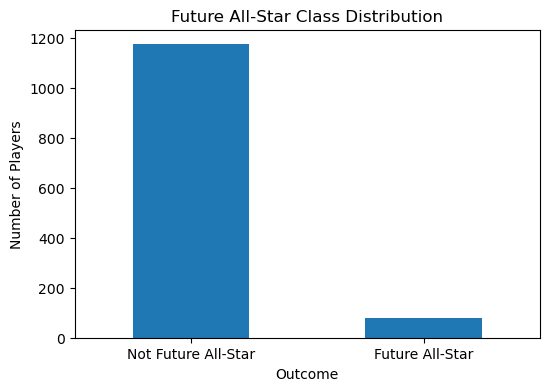

In [69]:
plt.figure(figsize=(6, 4))

df["future_all_star"].value_counts().sort_index().plot(kind="bar")

plt.xticks(
    [0, 1],
    ["Not Future All-Star", "Future All-Star"],
    rotation=0
)

plt.title("Future All-Star Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Players")
plt.savefig("project2_class_balance.png", bbox_inches="tight", dpi=150)
plt.show()


<Figure size 700x500 with 0 Axes>

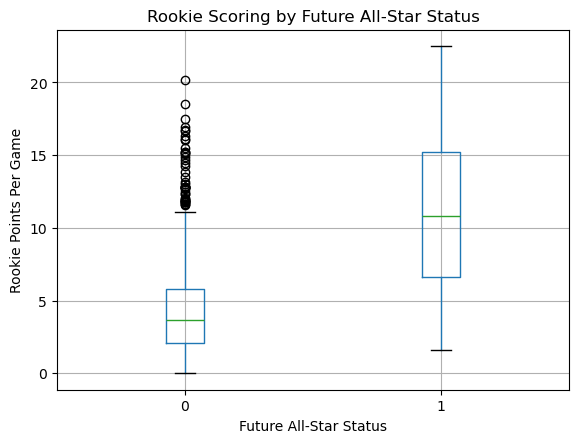

In [68]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="PPG",
    by="future_all_star"
)

plt.title("Rookie Scoring by Future All-Star Status")
plt.suptitle("")
plt.xlabel("Future All-Star Status")
plt.ylabel("Rookie Points Per Game")
plt.savefig("project2_rookie_ppg.png", bbox_inches="tight", dpi=150)
plt.show()


In [39]:
print("Missing targets:", df["future_all_star"].isnull().sum())

Missing targets: 0


## Feature Selection and Train/Test Split

The target variable is highly imbalanced, so I will use a stratified train/test split to preserve the proportion of future All-Stars in both sets.

The initial feature set includes rookie production, efficiency, playing time, age, draft position, and engineered per-36 and true-shooting measures.

In [40]:
features = [
    "PPG",
    "RPG",
    "APG",
    "SPG",
    "BPG",
    "TOV_PG",
    "MPG",
    "GP",
    "FG_PCT",
    "FG3_PCT",
    "FT_PCT",
    "AGE",
    "DRAFT_NUMBER_CLEAN",
    "PTS_PER36",
    "REB_PER36",
    "AST_PER36",
    "TS_PCT"
]

model_df = df[features + ["future_all_star"]].copy()

print(model_df.shape)
print(model_df.isnull().sum())

(1250, 18)
PPG                    0
RPG                    0
APG                    0
SPG                    0
BPG                    0
TOV_PG                 0
MPG                    0
GP                     0
FG_PCT                 0
FG3_PCT                0
FT_PCT                 0
AGE                    0
DRAFT_NUMBER_CLEAN     0
PTS_PER36              0
REB_PER36              0
AST_PER36              0
TS_PCT                13
future_all_star        0
dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X = model_df[features]
y = model_df["future_all_star"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (1000, 17)
Testing shape: (250, 17)

Training target distribution:
future_all_star
0    0.938
1    0.062
Name: proportion, dtype: float64

Testing target distribution:
future_all_star
0    0.94
1    0.06
Name: proportion, dtype: float64


## Baseline Model

Because most players in the dataset do not become All-Stars, a simple baseline model can predict the majority class for every player. The trained machine-learning models should outperform this baseline, especially on metrics that account for the minority All-Star class.

In [42]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:", round(accuracy_score(y_test, baseline_pred), 3))
print("Baseline Precision:", round(precision_score(y_test, baseline_pred, zero_division=0), 3))
print("Baseline Recall:", round(recall_score(y_test, baseline_pred, zero_division=0), 3))
print("Baseline F1:", round(f1_score(y_test, baseline_pred, zero_division=0), 3))

Baseline Accuracy: 0.94
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, logistic_pred), 3))

print("Logistic Regression Precision:",
      round(precision_score(y_test, logistic_pred, zero_division=0), 3))

print("Logistic Regression Recall:",
      round(recall_score(y_test, logistic_pred, zero_division=0), 3))

print("Logistic Regression F1:",
      round(f1_score(y_test, logistic_pred, zero_division=0), 3))

print("Logistic Regression ROC-AUC:",
      round(roc_auc_score(y_test, logistic_prob), 3))

Logistic Regression Accuracy: 0.836
Logistic Regression Precision: 0.229
Logistic Regression Recall: 0.733
Logistic Regression F1: 0.349
Logistic Regression ROC-AUC: 0.853


## Random Forest Model

The Random Forest model can capture nonlinear relationships and interactions between rookie statistics that Logistic Regression may miss.

Because the target variable is imbalanced, I will use balanced class weights so the minority All-Star class receives more attention during training.

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_pred), 3))

print("Random Forest Precision:",
      round(precision_score(y_test, rf_pred, zero_division=0), 3))

print("Random Forest Recall:",
      round(recall_score(y_test, rf_pred, zero_division=0), 3))

print("Random Forest F1:",
      round(f1_score(y_test, rf_pred, zero_division=0), 3))

print("Random Forest ROC-AUC:",
      round(roc_auc_score(y_test, rf_prob), 3))

Random Forest Accuracy: 0.948
Random Forest Precision: 0.75
Random Forest Recall: 0.2
Random Forest F1: 0.316
Random Forest ROC-AUC: 0.82


In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.940,
        0.836,
        0.948
    ],
    "Precision": [
        0.000,
        0.229,
        0.750
    ],
    "Recall": [
        0.000,
        0.733,
        0.200
    ],
    "F1": [
        0.000,
        0.349,
        0.316
    ],
    "ROC_AUC": [
        np.nan,
        0.853,
        0.820
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.940,0.000,0.000,0.000,NaN
1,Logistic Regression,0.836,0.229,0.733,0.349,0.853
2,Random Forest,0.948,0.750,0.200,0.316,0.820


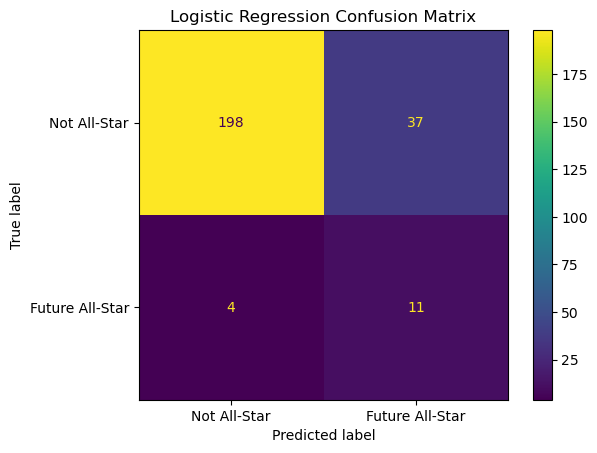

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=["Not All-Star", "Future All-Star"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("project2_logistic_confusion.png", bbox_inches="tight", dpi=150)
plt.show()


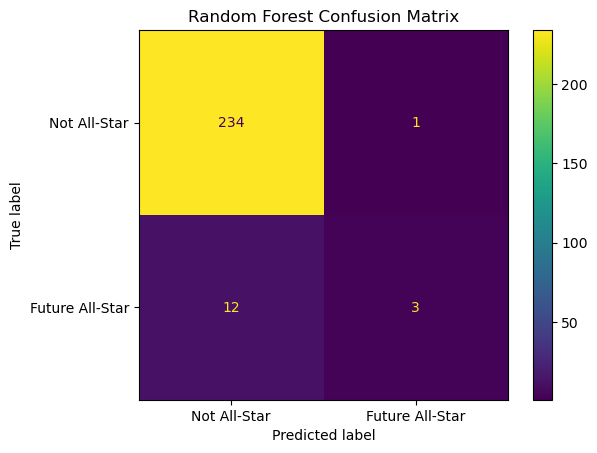

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Not All-Star", "Future All-Star"]
)

plt.title("Random Forest Confusion Matrix")
plt.savefig("project2_rf_confusion.png", bbox_inches="tight", dpi=150)
plt.show()


In [48]:
rf_importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_importances
}).sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
12,DRAFT_NUMBER_CLEAN,0.147001
7,GP,0.124501
6,MPG,0.112709
0,PPG,0.099924
1,RPG,0.075664
5,TOV_PG,0.072668
4,BPG,0.051522
3,SPG,0.043508
11,AGE,0.038304
8,FG_PCT,0.035478


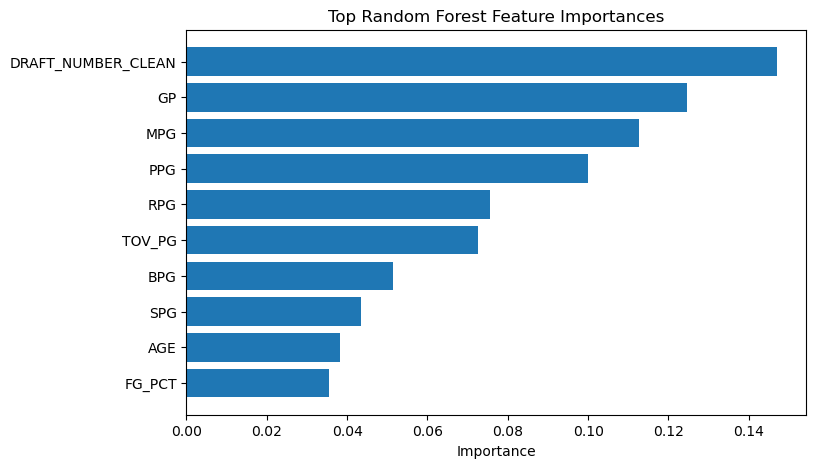

In [65]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.savefig("project2_rf_feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()


In [50]:
thresholds = np.arange(0.10, 0.81, 0.05)

results = []

for threshold in thresholds:
    preds = (logistic_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(results)

threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1
13,0.75,0.333333,0.533333,0.410256
12,0.70,0.310345,0.600000,0.409091
10,0.60,0.282051,0.733333,0.407407
9,0.55,0.255814,0.733333,0.379310
11,0.65,0.272727,0.600000,0.375000
14,0.80,0.315789,0.400000,0.352941
8,0.50,0.229167,0.733333,0.349206
7,0.45,0.222222,0.800000,0.347826
6,0.40,0.200000,0.800000,0.320000
4,0.30,0.183099,0.866667,0.302326


In [51]:
best_threshold = 0.75

logistic_pred_tuned = (
    logistic_prob >= best_threshold
).astype(int)

print("Tuned Logistic Accuracy:",
      round(accuracy_score(y_test, logistic_pred_tuned), 3))

print("Tuned Logistic Precision:",
      round(precision_score(y_test, logistic_pred_tuned, zero_division=0), 3))

print("Tuned Logistic Recall:",
      round(recall_score(y_test, logistic_pred_tuned, zero_division=0), 3))

print("Tuned Logistic F1:",
      round(f1_score(y_test, logistic_pred_tuned, zero_division=0), 3))

print("Tuned Logistic ROC-AUC:",
      round(roc_auc_score(y_test, logistic_prob), 3))

Tuned Logistic Accuracy: 0.908
Tuned Logistic Precision: 0.333
Tuned Logistic Recall: 0.533
Tuned Logistic F1: 0.41
Tuned Logistic ROC-AUC: 0.853


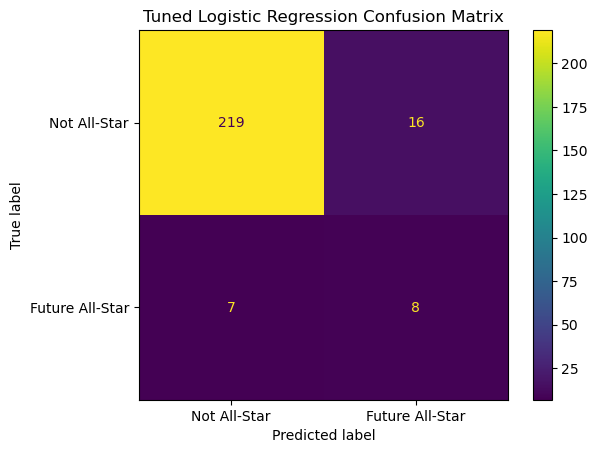

In [64]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred_tuned,
    display_labels=["Not All-Star", "Future All-Star"]
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.savefig("project2_logistic_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()


In [53]:
logistic_coefficients = logistic_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_coefficients
}).sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
0,PPG,1.340967
7,GP,1.273024
8,FG_PCT,0.941516
1,RPG,0.459938
2,APG,0.316700
4,BPG,0.286551
5,TOV_PG,0.162373
15,AST_PER36,0.067847
9,FG3_PCT,-0.027791
3,SPG,-0.123142


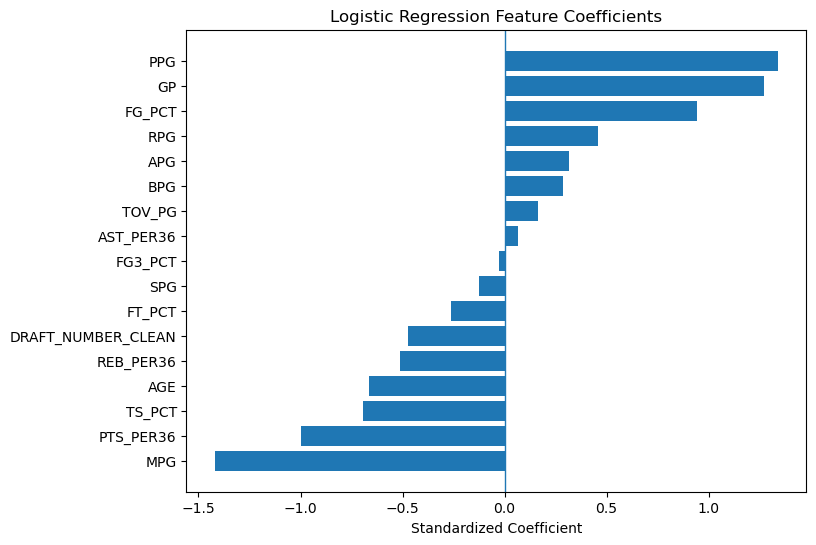

In [63]:
plt.figure(figsize=(8, 6))

coef_plot = coef_df.sort_values("Coefficient")

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Standardized Coefficient")
plt.savefig("project2_logistic_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()


## Final Model Interpretation

The Logistic Regression model showed that rookie points per game, games played, field-goal percentage, rebounds per game, and assists per game had the strongest positive coefficients.

Rookie points per game had the largest positive coefficient, suggesting that stronger early scoring production was associated with a higher predicted probability of becoming an All-Star within seven seasons.

Draft position had a negative coefficient. Because lower draft numbers represent earlier selections, this means players selected earlier in the draft were more likely to be predicted as future All-Stars.

Some variables, including minutes per game, points per 36 minutes, true shooting percentage, and rebounds per 36 minutes, had negative coefficients. These results should be interpreted cautiously because several of the model features measure similar aspects of player performance. For example, points per game, minutes per game, and points per 36 minutes are strongly related. When correlated predictors are included together, Logistic Regression coefficients can become difficult to interpret individually.

For this reason, the coefficients are best understood as the relationship between each feature and the prediction while holding the other included features constant, rather than as proof that any one statistic directly causes future All-Star success.

In [55]:
df.to_csv("project2_final_dataset.csv", index=False)
print("Saved project2_final_dataset.csv")

Saved project2_final_dataset.csv
